# Train a Simple MLP on MNIST

**Goal:** See the full training loop in code — forward pass → loss → backward → optimizer step.

MNIST: 70,000 handwritten digit images (0–9), 28×28 pixels, grayscale.

## Cell 1 — Imports

- `torch` — PyTorch core tensors and math
- `torch.nn` — layer types (Linear, ReLU, Dropout...) and loss functions
- `torch.optim` — optimizers (Adam, SGD) — this is where gradient descent lives
- `torchvision` — image datasets (MNIST built-in) and transforms
- `DataLoader` — the batch generator that feeds data to the model during training
- `matplotlib` — plotting loss curves and accuracy
- `numpy` — minimal use here; mainly for converting tensors when matplotlib needs it

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.8.0+cpu
CUDA available: False


In [17]:
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
EPOCHS        = 5
HIDDEN_SIZE   = 256
INPUT_SIZE    = 28 * 28  # 784
NUM_CLASSES   = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on:', device)
print(f'Each epoch = {60000 // BATCH_SIZE} weight updates')

Training on: cpu
Each epoch = 937 weight updates


## Cell 2 — Hyperparameters

Hyperparameters are settings *you* choose before training. The model never learns them — you set them manually and they control how learning happens.

| Hyperparameter | Value | What it controls |
|---|---|---|
| `BATCH_SIZE` | 64 | Images per weight update. 937 batches = 1 epoch over 60k images. |
| `LEARNING_RATE` | 0.001 | Step size per gradient update. Most sensitive knob — too high diverges, too low stalls. |
| `EPOCHS` | 5 | Full passes over the dataset. Each epoch = 937 weight updates. |
| `HIDDEN_SIZE` | 256 | Width of hidden layers (neurons per layer). Controls capacity, not depth. |
| `INPUT_SIZE` | 784 | 28×28 pixels flattened to a 1D vector. Fixed by MNIST. |
| `NUM_CLASSES` | 10 | One output score per digit (0–9). Fixed by the task. |

## Cell 3 — Load MNIST + DataLoader

Two steps to get data into the model:

**Transform pipeline** — converts each PIL image into a normalized float tensor:
- `ToTensor()` — PIL image (int 0–255) → float tensor (0.0–1.0), adds a channel dimension: shape becomes `(1, 28, 28)`
- `Normalize(mean=0.1307, std=0.3081)` — shifts values so mean≈0, std≈1. These are MNIST's pre-computed dataset statistics. Keeps gradients stable during training — raw 0–255 inputs cause large, unstable gradient magnitudes.

**DataLoader** — wraps the dataset into a batch generator:
- `shuffle=True` on train — randomizes order every epoch so the model doesn't memorize sequence
- `shuffle=False` on test — order doesn't matter, just need consistent evaluation

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')
print(f'Train batches : {len(train_loader)}')
print(f'Batch shape   : {next(iter(train_loader))[0].shape}')  # (64, 1, 28, 28)

Train samples : 60,000
Test samples  : 10,000
Train batches : 938
Batch shape   : torch.Size([64, 1, 28, 28])


## Cell 4 — Visualize the Data

Always look at your data before training. Catches bad preprocessing early.

Note: after `ToTensor()` each image has shape `(1, 28, 28)` — channel first. `.squeeze()` removes that leading `1` so matplotlib can plot the 28×28 grid.

Batch shape  : torch.Size([64, 1, 28, 28])
Labels shape : torch.Size([64])
Pixel range  : min=-0.42, max=2.82


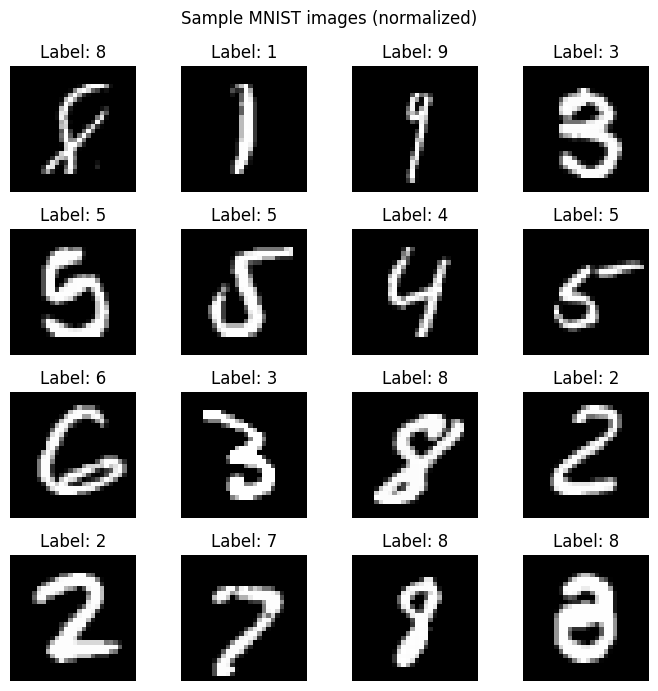

In [19]:
images, labels = next(iter(train_loader))

print('Batch shape  :', images.shape)   # (64, 1, 28, 28)
print('Labels shape :', labels.shape)   # (64,)
print('Pixel range  : min={:.2f}, max={:.2f}'.format(images.min().item(), images.max().item()))

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')  # squeeze: (1,28,28) → (28,28)
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample MNIST images (normalized)')
plt.tight_layout()
plt.show()

## Cell 5 — Define the MLP Model

Architecture: `(64, 1, 28, 28)` → Flatten → `(64, 784)` → Linear → ReLU → Linear → ReLU → Linear → `(64, 10)`

Every PyTorch model is a class inheriting from `nn.Module`. Two required methods:
- `__init__` — define the layers (the learnable parts)
- `forward(x)` — define how data flows through them. PyTorch builds the computation graph here for backprop.

**Layers:**
- `nn.Flatten()` — reshapes `(batch, 1, 28, 28)` → `(batch, 784)`. MLP needs a 1D input per sample.
- `nn.Linear(in, out)` — fully connected layer: computes `y = Wx + b`. The weights W and bias b are learned.
- `nn.ReLU()` — activation function: `max(0, x)`. Without it, stacking Linear layers is mathematically equivalent to a single Linear layer — they collapse. ReLU adds non-linearity.
- `nn.Dropout(0.2)` — during training, randomly zeros 20% of neuron outputs. Forces the network to learn redundant representations. Disabled automatically at eval time.

**Output is logits, not probabilities.** `CrossEntropyLoss` applies softmax internally — don't add softmax to the model or you'll double-apply it.

In [20]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),                                    # (batch, 1, 28, 28) → (batch, 784)

            nn.Linear(input_size, hidden_size),             # 784 → 256
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_size, hidden_size // 2),       # 256 → 128
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_size // 2, num_classes)        # 128 → 10  (logits, no softmax)
        )

    def forward(self, x):
        return self.network(x)


model = MLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)

print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 235,146


## Cell 6 — Loss Function + Optimizer

- **`CrossEntropyLoss`** — takes raw logits + true labels, applies softmax internally, returns a scalar loss. Used during training where we need gradients.
- **`Adam`** — optimizer that updates weights using gradients. Adapts learning rate per parameter. `model.parameters()` tells it which tensors to update.
- At prediction time we use `argmax` on logits directly — no loss function needed.

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print('Loss function:', criterion)
print('Optimizer    :', optimizer)

Loss function: CrossEntropyLoss()
Optimizer    : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Cell 7 — Training Loop

The 5-step cycle that runs for every batch. This is the heartbeat of all deep learning:

```
1. optimizer.zero_grad()    — clear gradients from the previous batch
2. outputs = model(inputs)  — forward pass: compute predictions
3. loss = criterion(...)    — compute how wrong the model is (scalar)
4. loss.backward()          — backprop: compute gradients for every weight
5. optimizer.step()         — update all weights using those gradients
```

**Why zero_grad first?** PyTorch accumulates gradients by default — it adds new gradients on top of old ones. Without zeroing, last batch's gradients corrupt this batch's update.

**eval loop** — structurally identical but two differences:
- `model.eval()` — disables Dropout (want deterministic predictions, not random zeros)
- `torch.no_grad()` — skips building the computation graph. No backward needed → saves memory and runs faster.

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # enables Dropout
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()              # 1. clear old gradients
        outputs = model(images)            # 2. forward pass → (batch, 10) logits
        loss = criterion(outputs, labels)  # 3. compute loss
        loss.backward()                    # 4. backprop → gradients on all weights
        optimizer.step()                   # 5. update weights

        total_loss += loss.item()
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()  # disables Dropout
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # no computation graph needed — saves memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


print('Functions defined. Ready to train.')

Functions defined. Ready to train.


## Cell 8 — Run Training

Calls the training and eval functions for each epoch. Records metrics so we can plot them.

Watch the numbers as it trains — loss should drop, accuracy should rise. If train accuracy >> test accuracy after a few epochs, the model is starting to overfit.

In [23]:
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

print(f'{"Epoch":<8} {"Train Loss":<14} {"Train Acc":<14} {"Test Loss":<14} {"Test Acc"}')
print('-' * 62)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f'Epoch {epoch:<3} {train_loss:<14.4f} {train_acc*100:<14.2f} {test_loss:<14.4f} {test_acc*100:.2f}%')

print('\nDone.')

Epoch    Train Loss     Train Acc      Test Loss      Test Acc
--------------------------------------------------------------
Epoch 1   0.2765         91.58          0.1126         96.51%
Epoch 2   0.1304         95.97          0.0941         96.98%
Epoch 3   0.1013         96.89          0.0789         97.47%
Epoch 4   0.0851         97.33          0.0765         97.75%
Epoch 5   0.0701         97.77          0.0630         98.08%

Done.


## Cell 9 — Plot Loss + Accuracy Curves

Two plots:
- **Loss curve** — should decrease smoothly each epoch
- **Accuracy curve** — train vs test. A widening gap = overfitting.

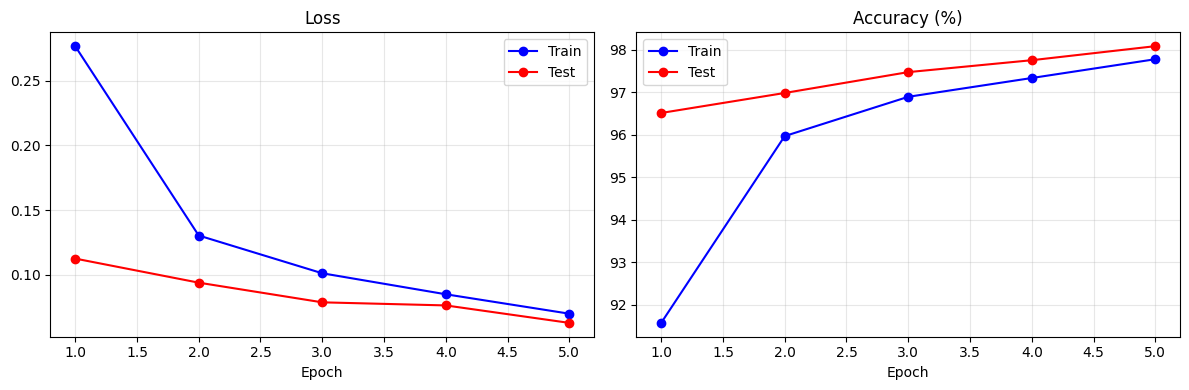

Final test accuracy: 98.08%


In [24]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, 'b-o', label='Train')
ax1.plot(epochs_range, test_losses,  'r-o', label='Test')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in train_accs], 'b-o', label='Train')
ax2.plot(epochs_range, [a*100 for a in test_accs],  'r-o', label='Test')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Final test accuracy: {test_accs[-1]*100:.2f}%')

## Cell 10 — Error Analysis

Look at what the model gets wrong. Common MNIST confusions: 4↔9, 3↔8, 1↔7.

This is professional habit — mistakes tell you where the model struggles and what to fix next.

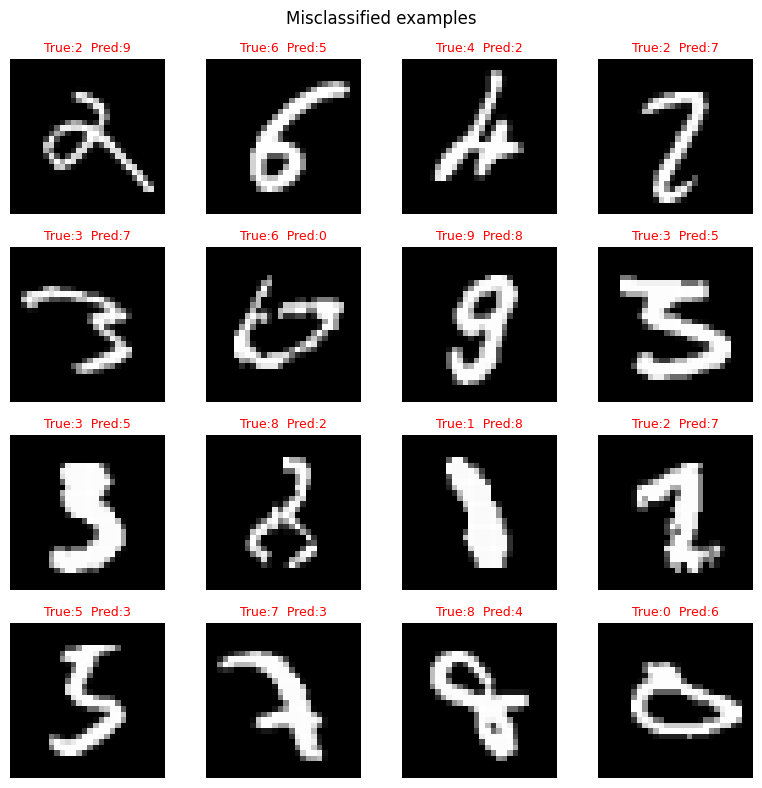

In [27]:
model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs   = model(images)
        predicted = outputs.argmax(dim=1)
        mask = (predicted != labels)
        wrong_images.extend(images[mask].cpu())
        wrong_true.extend(labels[mask].cpu())
        wrong_pred.extend(predicted[mask].cpu())
        if len(wrong_images) >= 16:
            break

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f'True:{wrong_true[i]}  Pred:{wrong_pred[i]}', color='red', fontsize=9)
    ax.axis('off')
plt.suptitle('Misclassified examples')
plt.tight_layout()
plt.show()

## Cell 11 — Save the Model

`state_dict()` saves only the weights — not the architecture. To reload, you recreate the model class first, then load weights into it.

In [28]:
import os

torch.save(model.state_dict(), 'mlp_mnist.pth')
size_kb = os.path.getsize('mlp_mnist.pth') / 1024
print(f'Saved mlp_mnist.pth ({size_kb:.1f} KB)')

# Verify reload works
model_loaded = MLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES).to(device)
model_loaded.load_state_dict(torch.load('mlp_mnist.pth', map_location=device))
model_loaded.eval()

_, reloaded_acc = evaluate(model_loaded, test_loader, criterion, device)
print(f'Reloaded accuracy: {reloaded_acc*100:.2f}%  (should match {test_accs[-1]*100:.2f}%)')

Saved mlp_mnist.pth (921.7 KB)
Reloaded accuracy: 98.08%  (should match 98.08%)
